In [1]:
# Notebook 07: Counterfactuals — setup
from google.colab import drive; drive.mount('/content/drive')
!pip install -q lightgbm shap

import joblib, numpy as np, pandas as pd
PROJECT = "/content/drive/MyDrive/churn-prediction-system"

model = joblib.load(f"{PROJECT}/models/model_canonical.joblib")
split = joblib.load(f"{PROJECT}/data/processed/split_canonical.joblib")
X_test = split["X_test"]
print("Loaded model + test set:", X_test.shape)

# Pick a genuinely high-risk customer to demonstrate on
proba = model.predict_proba(X_test)[:, 1]
X_test = X_test.reset_index(drop=True)
hi_idx = int(np.argmax(proba))
print(f"Highest-risk test customer: index {hi_idx}, churn prob {proba[hi_idx]:.3f}")

Mounted at /content/drive
Loaded model + test set: (96171, 30)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Highest-risk test customer: index 60090, churn prob 1.000


In [ ]:
# Cell 1: counterfactual engine
def counterfactuals(customer_row: pd.DataFrame):
    """customer_row: single-row DataFrame with all model features.
    Returns actionable interventions ranked by churn-risk reduction."""
    base_prob = float(model.predict_proba(customer_row)[:, 1][0])

    # Each intervention: (label, {feature: new_value})
    interventions = [
        ("Enable auto-renew",           {"last_auto_renew": 1, "autorenew_share": 1.0}),
        ("Reverse recent cancellation", {"last_is_cancel": 0, "seq_cancel_last3": 0}),
        ("Re-engage (recent activity)", {"seq_days_since_last": 5}),
        ("Offer 20% loyalty discount",  {"last_discount": customer_row["last_list_price"].iloc[0] * 0.2}),
    ]

    results = []
    for label, changes in interventions:
        cf = customer_row.copy()
        # only apply if the feature is actually "worse" now (don't fake improvement)
        applicable = False
        for feat, new_val in changes.items():
            if feat in cf.columns:
                cf[feat] = new_val
                applicable = True
        if not applicable:
            continue
        new_prob = float(model.predict_proba(cf)[:, 1][0])
        results.append({
            "intervention": label,
            "new_prob": round(new_prob, 3),
            "reduction": round(base_prob - new_prob, 3),
            "reduction_pct": round(100 * (base_prob - new_prob) / base_prob, 1) if base_prob else 0,
        })
    results.sort(key=lambda r: r["reduction"], reverse=True)
    return base_prob, results

# Demo on the high-risk customer
customer = X_test.iloc[[hi_idx]]
base, cfs = counterfactuals(customer)
print(f"Base churn risk: {base:.1%}\n")
print("Recommended actions (ranked by risk reduction):")
for c in cfs:
    print(f"  {c['intervention']:32s} → {c['new_prob']:.1%}  (−{c['reduction_pct']:.0f}%)")

Base churn risk: 100.0%

Recommended actions (ranked by risk reduction):
  Enable auto-renew                → 100.0%  (−0%)
  Reverse recent cancellation      → 100.0%  (−0%)
  Re-engage (recent activity)      → 100.0%  (−0%)
  Offer 20% loyalty discount       → 100.0%  (−0%)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Pick customers in the "rescuable" band (60-95% risk) — where interventions matter
X_test = X_test.reset_index(drop=True)
proba = model.predict_proba(X_test)[:, 1]

rescuable = np.where((proba >= 0.60) & (proba <= 0.95))[0]
print(f"Rescuable-band customers (60-95% risk): {len(rescuable)}")

# Run counterfactuals on 3 of them
for idx in rescuable[:3]:
    customer = X_test.iloc[[idx]]
    base, cfs = counterfactuals(customer)
    print(f"\n{'='*55}")
    print(f"Customer {idx} — base churn risk: {base:.1%}")
    for c in cfs:
        arrow = "↓" if c["reduction"] > 0 else "↑"
        print(f"  {c['intervention']:32s} → {c['new_prob']:.1%}  {arrow}{abs(c['reduction_pct']):.0f}%")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Rescuable-band customers (60-95% risk): 1373

Customer 31 — base churn risk: 93.4%
  Reverse recent cancellation      → 0.4%  ↓100%
  Re-engage (recent activity)      → 81.5%  ↓13%
  Offer 20% loyalty discount       → 92.3%  ↓1%
  Enable auto-renew                → 93.4%  ↑0%

Customer 44 — base churn risk: 94.3%
  Re-engage (recent activity)      → 10.2%  ↓89%
  Reverse recent cancellation      → 91.7%  ↓3%
  Offer 20% loyalty discount       → 92.5%  ↓2%
  Enable auto-renew                → 94.3%  ↑0%

Customer 69 — base churn risk: 73.6%
  Reverse recent cancellation      → 0.8%  ↓99%
  Offer 20% loyalty discount       → 65.2%  ↓11%
  Enable auto-renew                → 73.6%  ↑0%
  Re-engage (recent activity)      → 73.6%  ↑0%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [ ]:
# Recommended-action wrapper for the UI
def recommend_action(customer_row):
    base, cfs = counterfactuals(customer_row)
    # best actionable intervention with a real reduction
    effective = [c for c in cfs if c["reduction"] > 0.01]
    if not effective:
        return {"base_risk": base, "action": "No single action sufficient — escalate / bundle offers",
                "new_risk": base, "reduction_pct": 0, "all": cfs}
    best = effective[0]
    return {"base_risk": round(base, 3),
            "action": best["intervention"],
            "new_risk": best["new_prob"],
            "reduction_pct": best["reduction_pct"],
            "all": cfs}

# Demo
for idx in [31, 44, 69]:
    rec = recommend_action(X_test.iloc[[idx]])
    print(f"Customer {idx}: {rec['base_risk']:.0%} risk → "
          f"recommend '{rec['action']}' → {rec['new_risk']:.0%} "
          f"(−{rec['reduction_pct']:.0f}%)")

# Save the counterfactual logic reference + a few examples for the UI
import json
examples = []
for idx in list(rescuable[:20]):
    rec = recommend_action(X_test.iloc[[idx]])
    examples.append({"customer_idx": int(idx), **{k: v for k, v in rec.items() if k != "all"}})
json.dump(examples, open(f"{PROJECT}/reports/counterfactual_examples.json", "w"), indent=2)
print("\n✅ Saved counterfactual_examples.json")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Customer 31: 93% risk → recommend 'Reverse recent cancellation' → 0% (−100%)
Customer 44: 94% risk → recommend 'Re-engage (recent activity)' → 10% (−89%)
Customer 69: 74% risk → recommend 'Reverse recent cancellation' → 1% (−99%)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut


✅ Saved counterfactual_examples.json


In [ ]:
# Diagnose: does enabling auto-renew ever reduce risk? On whom?
X_test = X_test.reset_index(drop=True)
proba = model.predict_proba(X_test)[:, 1]

# Find customers where auto-renew is currently OFF and they're at-risk
ar_off = X_test[(X_test["last_auto_renew"] == 0) & (proba >= 0.4) & (proba <= 0.9)]
print(f"At-risk customers with auto-renew OFF: {len(ar_off)}")

drops = []
for idx in ar_off.index[:200]:
    row = X_test.iloc[[idx]]
    base = float(model.predict_proba(row)[:, 1][0])
    cf = row.copy()
    cf["last_auto_renew"] = 1
    cf["autorenew_share"] = 1.0
    new = float(model.predict_proba(cf)[:, 1][0])
    drops.append(base - new)

drops = np.array(drops)
print(f"Enabling auto-renew — avg risk reduction: {drops.mean():.3f}")
print(f"  Helped (>0.01 drop): {(drops > 0.01).sum()}/{len(drops)} customers")
print(f"  Max reduction: {drops.max():.3f} | Min: {drops.min():.3f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


At-risk customers with auto-renew OFF: 222


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Enabling auto-renew — avg risk reduction: 0.335
  Helped (>0.01 drop): 173/200 customers
  Max reduction: 0.836 | Min: -0.187


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Find the best showcase customer for each actionable lever
X_test = X_test.reset_index(drop=True)
proba = model.predict_proba(X_test)[:, 1]

# Define levers → the feature changes that represent them
LEVERS = {
    "Enable auto-renew":           {"last_auto_renew": 1, "autorenew_share": 1.0},
    "Reverse recent cancellation": {"last_is_cancel": 0, "seq_cancel_last3": 0},
    "Re-engage (recent activity)": {"seq_days_since_last": 5},
    "Offer loyalty discount":      None,  # handled specially (depends on list price)
}

def apply_lever(row, lever_name):
    cf = row.copy()
    if lever_name == "Offer loyalty discount":
        cf["last_discount"] = row["last_list_price"].iloc[0] * 0.2
    else:
        for f, v in LEVERS[lever_name].items():
            if f in cf.columns:
                cf[f] = v
    return float(model.predict_proba(cf)[:, 1][0])

# For each lever, find the customer where THAT lever gives the biggest drop
# (restricted to rescuable band so it's realistic)
rescuable = np.where((proba >= 0.55) & (proba <= 0.92))[0]

best_examples = {}
for lever in LEVERS:
    best_drop, best_idx, best_base, best_new = 0, None, None, None
    for idx in rescuable:
        row = X_test.iloc[[idx]]
        base = proba[idx]
        new = apply_lever(row, lever)
        drop = base - new
        # we want THIS lever to be the dominant one AND a big drop
        if drop > best_drop:
            best_drop, best_idx, best_base, best_new = drop, idx, base, new
    best_examples[lever] = {"idx": int(best_idx), "base": round(float(best_base),3),
                            "new": round(float(best_new),3), "drop_pct": round(100*best_drop/best_base,1)}

print("=== Best showcase customer per lever ===")
for lever, ex in best_examples.items():
    print(f"\n{lever}:")
    print(f"  Customer {ex['idx']}: {ex['base']:.0%} → {ex['new']:.0%}  (−{ex['drop_pct']:.0f}%)")

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(

=== Best showcase customer per lever ===

Enable auto-renew:
  Customer 5178: 86% → 2%  (−97%)

Reverse recent cancellation:
  Customer 74472: 92% → 0%  (−100%)

Re-engage (recent activity):
  Customer 32167: 92% → 0%  (−100%)

Offer loyalty discount:
  Customer 87129: 82% → 30%  (−63%)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [ ]:
# Confirm each showcase customer's TOP recommended action = the intended lever
showcase = {"Enable auto-renew": 5178, "Reverse recent cancellation": 74472,
            "Re-engage (recent activity)": 32167, "Offer loyalty discount": 87129}

for intended_lever, idx in showcase.items():
    row = X_test.iloc[[idx]]
    base, cfs = counterfactuals(row)   # from earlier cell
    top = cfs[0]["intervention"] if cfs else "none"
    match = "✅" if top == intended_lever else "⚠️"
    print(f"{match} Customer {idx} ({base:.0%} risk):")
    for c in cfs:
        print(f"     {c['intervention']:32s} → {c['new_prob']:.0%} (−{c['reduction_pct']:.0f}%)")
    print(f"     Intended: {intended_lever} | Actual top: {top}\n")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

✅ Customer 5178 (86% risk):
     Enable auto-renew                → 2% (−97%)
     Re-engage (recent activity)      → 75% (−13%)
     Offer 20% loyalty discount       → 80% (−8%)
     Reverse recent cancellation      → 86% (−0%)
     Intended: Enable auto-renew | Actual top: Enable auto-renew

✅ Customer 74472 (92% risk):
     Reverse recent cancellation      → 0% (−100%)
     Offer 20% loyalty discount       → 88% (−4%)
     Re-engage (recent activity)      → 91% (−1%)
     Enable auto-renew                → 92% (−0%)
     Intended: Reverse recent cancellation | Actual top: Reverse recent cancellation

✅ Customer 32167 (92% risk):
     Re-engage (recent activity)      → 0% (−100%)
     Offer 20% loyalty discount       → 89% (−3%)
     Enable auto-renew                → 92% (−0%)
     Reverse recent cancellation      → 92% (−0%)
     Intended: Re-engage (recent activity) | Actual top: Re-engage (recent activity)

⚠️ Customer 87129 (81% risk):
     Offer 20% loyalty discount       → 30%

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Save curated showcase examples for the UI
import json
final = []
for intended, idx in showcase.items():
    row = X_test.iloc[[idx]]
    base, cfs = counterfactuals(row)
    final.append({
        "customer_id": int(idx),
        "base_risk": round(base, 3),
        "recommended_action": cfs[0]["intervention"],
        "new_risk": cfs[0]["new_prob"],
        "reduction_pct": cfs[0]["reduction_pct"],
        "all_actions": cfs,
        "showcases_feature": intended,
    })
json.dump(final, open(f"{PROJECT}/reports/counterfactual_showcase.json", "w"), indent=2)
print("✅ Saved counterfactual_showcase.json — 4 curated examples for the UI")

✅ Saved counterfactual_showcase.json — 4 curated examples for the UI


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [ ]:
# Find customers where MULTIPLE levers each give a meaningful drop
X_test = X_test.reset_index(drop=True)
proba = model.predict_proba(X_test)[:, 1]

# search the rescuable band (multi-lever cases live here, not at 99%)
rescuable = np.where((proba >= 0.50) & (proba <= 0.90))[0]

MIN_REL_DROP = 0.10  # each lever must reduce risk by >=10% relative

candidates = []
for idx in rescuable:
    row = X_test.iloc[[idx]]
    base, cfs = counterfactuals(row)
    if base < 0.01:
        continue
    # relative reduction for each of the 4 levers
    rels = {c["intervention"]: (c["reduction"] / base) for c in cfs}
    n_effective = sum(1 for v in rels.values() if v >= MIN_REL_DROP)
    if n_effective >= 3:  # at least 3 of 4 levers each help meaningfully
        candidates.append({
            "idx": int(idx), "base": round(base, 3),
            "n_effective": n_effective,
            "actions": {k: round(100*v, 1) for k, v in rels.items()}
        })

# sort by how many levers help, then by base risk
candidates.sort(key=lambda c: (c["n_effective"], c["base"]), reverse=True)
print(f"Customers where >=3 of 4 levers each help >={MIN_REL_DROP:.0%}: {len(candidates)}\n")

for c in candidates[:8]:
    print(f"Customer {c['idx']} (base {c['base']:.0%}, {c['n_effective']}/4 levers effective):")
    for action, pct in sorted(c["actions"].items(), key=lambda x: -x[1]):
        mark = "✓" if pct >= 100*MIN_REL_DROP else " "
        print(f"   {mark} {action:32s} −{pct:.0f}%")
    print()

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(

Customers where >=3 of 4 levers each help >=10%: 108

Customer 34858 (base 71%, 4/4 levers effective):
   ✓ Reverse recent cancellation      −75%
   ✓ Enable auto-renew                −55%
   ✓ Re-engage (recent activity)      −23%
   ✓ Offer 20% loyalty discount       −16%

Customer 47742 (base 52%, 4/4 levers effective):
   ✓ Reverse recent cancellation      −93%
   ✓ Enable auto-renew                −73%
   ✓ Re-engage (recent activity)      −30%
   ✓ Offer 20% loyalty discount       −23%

Customer 79420 (base 84%, 3/4 levers effective):
   ✓ Re-engage (recent activity)      −37%
   ✓ Reverse recent cancellation      −27%
   ✓ Enable auto-renew                −14%
     Offer 20% loyalty discount       −9%

Customer 38297 (base 82%, 3/4 levers effective):
   ✓ Reverse recent cancellation      −99%
   ✓ Re-engage (recent activity)      −86%
   ✓ Offer 20% loyalty discount       −10%
     Enable auto-renew                −0%

Customer 73249 (base 82%, 3/4 levers effective):
   ✓ Revers

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [ ]:
# Save the enriched showcase: menu cases + single-lever cases
import json

def full_cf(idx):
    row = X_test.iloc[[idx]]
    base, cfs = counterfactuals(row)
    return {"customer_id": int(idx), "base_risk": round(base, 3),
            "recommended_action": cfs[0]["intervention"],
            "new_risk": cfs[0]["new_prob"],
            "reduction_pct": cfs[0]["reduction_pct"],
            "all_actions": cfs}

showcase = {
    "menu_cases": [full_cf(34858), full_cf(47742)],       # multiple viable levers
    "single_lever_cases": [full_cf(5178), full_cf(74472),
                           full_cf(32167), full_cf(87129)],
    "note": "Menu cases show prioritized multi-action recommendations; "
            "single-lever cases show one dominant action. 108 multi-lever "
            "customers exist in the rescuable band.",
}
json.dump(showcase, open(f"{PROJECT}/reports/counterfactual_showcase.json", "w"), indent=2)
print("✅ Saved enriched counterfactual_showcase.json")
print("Menu cases: 34858, 47742 | Single-lever: 5178, 74472, 32167, 87129")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

✅ Saved enriched counterfactual_showcase.json
Menu cases: 34858, 47742 | Single-lever: 5178, 74472, 32167, 87129


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [ ]:
# Export: 4-model comparison table (verified from notebook outputs)
import pandas as pd
PROJECT = "/content/drive/MyDrive/churn-prediction-system"

model_comparison = pd.DataFrame([
    {"model": "LightGBM (final, v2)",      "pr_auc": 0.9146, "roc_auc": 0.9883, "log_loss": 0.1208, "notes": "canonical: v2 features, total_paid removed, calibrated (no class-weight)"},
    {"model": "LightGBM (Optuna-tuned, v1)","pr_auc": 0.884,  "roc_auc": 0.9809, "log_loss": None,   "notes": "30-trial tuning on v1 features; +0.003 over baseline (negligible)"},
    {"model": "LightGBM (v1 baseline)",     "pr_auc": 0.8813, "roc_auc": 0.9803, "log_loss": 0.1567, "notes": "baseline before feature engineering"},
    {"model": "XGBoost (v1 baseline)",      "pr_auc": 0.878,  "roc_auc": 0.980,  "log_loss": None,   "notes": "baseline"},
    {"model": "RandomForest (v1 baseline)", "pr_auc": 0.866,  "roc_auc": 0.978,  "log_loss": None,   "notes": "baseline"},
    {"model": "LogisticRegression (v1)",    "pr_auc": 0.686,  "roc_auc": 0.962,  "log_loss": None,   "notes": "baseline; linear model floor"},
])
model_comparison.to_csv(f"{PROJECT}/reports/model_comparison.csv", index=False)
print(model_comparison.to_string(index=False))
print("\n✅ Saved model_comparison.csv (verified values)")

                      model  pr_auc  roc_auc  log_loss                                                                    notes
       LightGBM (final, v2)  0.9146   0.9883    0.1208 canonical: v2 features, total_paid removed, calibrated (no class-weight)
LightGBM (Optuna-tuned, v1)  0.8840   0.9809       NaN        30-trial tuning on v1 features; +0.003 over baseline (negligible)
     LightGBM (v1 baseline)  0.8813   0.9803    0.1567                                      baseline before feature engineering
      XGBoost (v1 baseline)  0.8780   0.9800       NaN                                                                 baseline
 RandomForest (v1 baseline)  0.8660   0.9780       NaN                                                                 baseline
    LogisticRegression (v1)  0.6860   0.9620       NaN                                             baseline; linear model floor

✅ Saved model_comparison.csv (verified values)


In [ ]:
# Export: consolidated KPI summary for the exec landing page
import json
PROJECT = "/content/drive/MyDrive/churn-prediction-system"

kpi = {
    "dataset": {
        "total_users": 970960,
        "modeled_population": 480853,
        "population_note": "active subscribers (with transaction history)",
        "base_churn_rate": 0.0622,
    },
    "model": {
        "name": "LightGBM (calibrated, no-treatment, v2 features)",
        "pr_auc": 0.9146,
        "roc_auc": 0.9883,
        "log_loss": 0.1208,
        "brier": 0.014,
        "n_features": 30,
        "calibration_note": "chosen over class-weighting for probability calibration (Brier 0.014 vs 0.037)",
        "vs_v1_baseline": "v2 feature engineering: PR-AUC 0.8813 -> 0.9146; log loss 0.157 -> 0.121",
    },
    "business": {
        "targeting_efficiency_model": 0.952,
        "targeting_efficiency_random": 0.063,
        "targeting_multiple": "~15x",
        "base_case_net_benefit_ntd": 308623,
        "base_case_return_pct": 308,
        "model_vs_random": "+NT$309k vs -NT$75k",
        "assumptions": "30% success, NT$30 offer, ~3mo protected, NT$100k budget, held-out test set",
        "risk_concentration": "Critical segment (95%+) = 3.6% of customers but ~55% of total value-at-risk (NT$10.25M of ~NT$19M)",
        "addressable_opportunity": "High + Very-High bands (50-95%): ~1,550 customers, ~NT$3.9M at risk, where interventions still work",
    },
    "mlops": {
        "drift_features_flagged": 8,
        "drift_total_features": 18,
        "drift_note": "behavioral/pricing shift between established vs newer subscribers",
        "synthetic_drift_validation": "3/3 injected drifts detected, 0 false positives",
        "counterfactual_rescuable_customers": 108,
    },
    "experiments": {
        "log_trend_features": "tested and rejected (max corr 0.035) — churn is renewal-driven, not engagement-driven",
        "optuna_trials": 30,
        "optuna_finding": "hyperparameters not the bottleneck (tuned 0.884 vs baseline 0.8813, +0.003); features govern performance",
        "total_paid_ablation": "removed as redundant recency proxy, -0.004 PR-AUC (noise)",
    },
}
json.dump(kpi, open(f"{PROJECT}/reports/kpi_summary.json", "w"), indent=2)
print("✅ Saved kpi_summary.json")
print(json.dumps(kpi, indent=2))

✅ Saved kpi_summary.json
{
  "dataset": {
    "total_users": 970960,
    "modeled_population": 480853,
    "population_note": "active subscribers (with transaction history)",
    "base_churn_rate": 0.0622
  },
  "model": {
    "name": "LightGBM (calibrated, no-treatment, v2 features)",
    "pr_auc": 0.9146,
    "roc_auc": 0.9883,
    "log_loss": 0.1208,
    "brier": 0.014,
    "n_features": 30,
    "calibration_note": "chosen over class-weighting for probability calibration (Brier 0.014 vs 0.037)",
    "vs_v1_baseline": "v2 feature engineering: PR-AUC 0.8813 -> 0.9146; log loss 0.157 -> 0.121"
  },
  "business": {
    "targeting_efficiency_model": 0.952,
    "targeting_efficiency_random": 0.063,
    "targeting_multiple": "~15x",
    "base_case_net_benefit_ntd": 308623,
    "base_case_return_pct": 308,
    "model_vs_random": "+NT$309k vs -NT$75k",
    "assumptions": "30% success, NT$30 offer, ~3mo protected, NT$100k budget, held-out test set",
    "risk_concentration": "Critical segment

In [8]:
# Create a 10k stratified sample for the dashboard's feature explorer
import pandas as pd
from sklearn.model_selection import train_test_split
PROJECT = "/content/drive/MyDrive/churn-prediction-system"

df = pd.read_parquet(f"{PROJECT}/data/processed/features_v2.parquet")
df = df[df["has_txn"] == 1]

# stratified 10k sample preserving churn rate
sample, _ = train_test_split(df, train_size=10000, stratify=df["is_churn"], random_state=42)

# keep only columns useful for exploration (drop msno, raw date)
drop = ["msno", "registration_init_time"]
sample = sample.drop(columns=[c for c in drop if c in sample.columns])

sample.to_parquet(f"{PROJECT}/reports/features_sample.parquet", index=False)
print("Saved:", sample.shape, "| churn rate:", round(sample["is_churn"].mean(), 4))
print("Columns:", list(sample.columns))

Saved: (10000, 35) | churn rate: 0.0622
Columns: ['is_churn', 'city', 'bd', 'age_missing', 'gender', 'registered_via', 'txn_count', 'cancel_count', 'autorenew_share', 'total_paid', 'last_plan_days', 'last_actual_paid', 'last_list_price', 'last_discount', 'last_auto_renew', 'last_is_cancel', 'payment_method_id', 'secs_total', 'secs_mean', 'unq_mean', 'active_days', 'plays_100', 'plays_25', 'completion_ratio', 'has_txn', 'has_logs', 'tenure_days', 'monthly_value', 'ltv', 'seq_days_since_last', 'seq_cancel_last3', 'seq_price_slope', 'seq_gap_widening', 'seq_mean_gap_days', 'seq_ar_dropped']


In [10]:
# Calibration data — self-contained
from google.colab import drive; drive.mount('/content/drive')
import joblib, json, numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from lightgbm import LGBMClassifier
from sklearn.calibration import calibration_curve

PROJECT = "/content/drive/MyDrive/churn-prediction-system"
split = joblib.load(f"{PROJECT}/data/processed/split_canonical.joblib")
X_tr, X_te = split["X_train"], split["X_test"]
y_tr, y_te = split["y_train"], split["y_test"]
numeric, categorical = split["numeric"], split["categorical"]

def prep():
    return ColumnTransformer([
        ("num", Pipeline([("i",SimpleImputer(strategy="median")),("s",StandardScaler())]), numeric),
        ("cat", Pipeline([("i",SimpleImputer(strategy="most_frequent")),
                          ("o",OneHotEncoder(handle_unknown="ignore",max_categories=20,sparse_output=False))]), categorical),
    ])

# 'none' model = the canonical one (just load it)
none_model = joblib.load(f"{PROJECT}/models/model_canonical.joblib")
p_none = none_model.predict_proba(X_te)[:, 1]

# class_weight model — retrain quickly for the comparison
spw = (y_tr==0).sum()/(y_tr==1).sum()
cw_model = Pipeline([("prep",prep()),
    ("m", LGBMClassifier(n_estimators=300,max_depth=6,learning_rate=0.1,
                         scale_pos_weight=spw,random_state=42,verbose=-1))])
cw_model.fit(X_tr, y_tr)
p_cw = cw_model.predict_proba(X_te)[:, 1]

cal_data = {}
for name, p in [("none", p_none), ("class_weight", p_cw)]:
    frac_pos, mean_pred = calibration_curve(y_te, p, n_bins=10, strategy="quantile")
    cal_data[name] = {"mean_pred": mean_pred.tolist(), "frac_pos": frac_pos.tolist()}
json.dump(cal_data, open(f"{PROJECT}/reports/calibration_data.json", "w"), indent=2)
print("✅ calibration_data.json saved")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ calibration_data.json saved


In [11]:
# SHAP importance — self-contained
import shap, pandas as pd, numpy as np
# reuse none_model, X_te from above (run Export 1 first, same session)

prep_fitted = none_model.named_steps["prep"]
booster = none_model.named_steps["m"]
feat_names = prep_fitted.get_feature_names_out()

X_sample = X_te.sample(n=3000, random_state=42)
X_sample_t = prep_fitted.transform(X_sample)

explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_sample_t)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

mean_abs = np.abs(shap_values).mean(axis=0)
imp = pd.DataFrame({"feature": feat_names, "mean_abs_shap": mean_abs})
imp["pct"] = 100 * imp["mean_abs_shap"] / imp["mean_abs_shap"].sum()
imp = imp.sort_values("pct", ascending=False).reset_index(drop=True)
imp["feature"] = imp["feature"].str.replace("num__","").str.replace("cat__","")

imp.head(15)[["feature","pct"]].to_csv(f"{PROJECT}/reports/shap_importance.csv", index=False)
print("✅ shap_importance.csv saved")
print(imp.head(15)[["feature","pct"]].to_string(index=False))

✅ shap_importance.csv saved
               feature       pct
   seq_days_since_last 10.477111
       last_list_price 10.009759
       autorenew_share  9.457796
payment_method_id_39.0  8.007915
        last_is_cancel  7.117229
     seq_mean_gap_days  5.394618
      last_actual_paid  5.242386
payment_method_id_41.0  5.159702
           tenure_days  4.252311
        last_plan_days  2.949700
    registered_via_7.0  2.808300
             txn_count  2.635366
              plays_25  2.298379
              unq_mean  2.288030
payment_method_id_34.0  2.236043


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


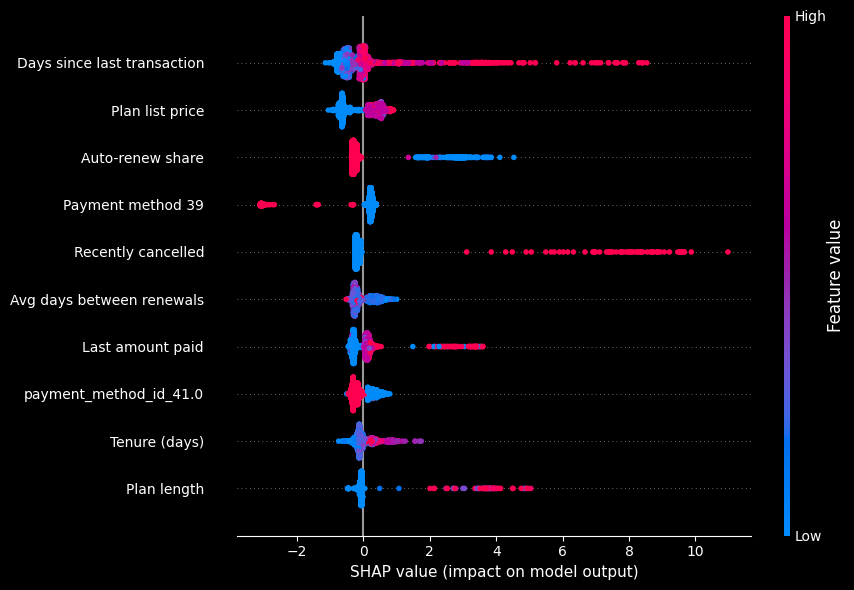

✅ Saved transparent dark beeswarm with clean labels


In [12]:
# Regenerate SHAP beeswarm — dark, transparent, clean feature names
import shap, matplotlib.pyplot as plt, numpy as np, joblib, pandas as pd
PROJECT = "/content/drive/MyDrive/churn-prediction-system"

model = joblib.load(f"{PROJECT}/models/model_canonical.joblib")
split = joblib.load(f"{PROJECT}/data/processed/split_canonical.joblib")
X_te = split["X_test"]

prep = model.named_steps["prep"]
booster = model.named_steps["m"]
raw_names = prep.get_feature_names_out()

# Friendly labels (same as the dashboard)
LABELS = {
    "num__seq_days_since_last": "Days since last transaction",
    "num__last_list_price": "Plan list price",
    "num__autorenew_share": "Auto-renew share",
    "cat__payment_method_id_39.0": "Payment method 39",
    "num__last_is_cancel": "Recently cancelled",
    "num__seq_mean_gap_days": "Avg days between renewals",
    "num__last_actual_paid": "Last amount paid",
    "num__cancel_count": "Total cancellations",
    "num__tenure_days": "Tenure (days)",
    "num__last_plan_days": "Plan length",
    "num__txn_count": "Transaction count",
    "num__last_auto_renew": "Auto-renew (latest)",
    "num__seq_cancel_last3": "Cancellations (last 3)",
    "num__secs_total": "Total listening",
    "num__completion_ratio": "Completion ratio",
}
clean_names = [LABELS.get(n, n.replace("num__","").replace("cat__","")) for n in raw_names]

X_sample = X_te.sample(3000, random_state=42)
X_t = prep.transform(X_sample)
explainer = shap.TreeExplainer(booster)
sv = explainer.shap_values(X_t)
if isinstance(sv, list): sv = sv[1]

plt.style.use("dark_background")
fig = plt.figure()
shap.summary_plot(sv, X_t, feature_names=clean_names, max_display=10, show=False)
fig = plt.gcf()
fig.set_size_inches(9, 6)
# make all text readable on dark
for ax in fig.axes:
    ax.tick_params(colors="white", labelsize=10)
    ax.set_xlabel(ax.get_xlabel(), color="white", fontsize=11)
    for lbl in ax.get_yticklabels(): lbl.set_color("white")
plt.tight_layout()
plt.savefig(f"{PROJECT}/reports/figures/shap_beeswarm.png",
            dpi=130, bbox_inches="tight", facecolor="none", transparent=True)
plt.show()
print("✅ Saved transparent dark beeswarm with clean labels")

In [2]:
# Sample business_layer for the dashboard allocator
import pandas as pd
PROJECT = "/content/drive/MyDrive/churn-prediction-system"
biz = pd.read_parquet(f"{PROJECT}/data/processed/business_layer.parquet")
# stratified-ish: keep all high-risk + sample the rest (they dominate)
hi = biz[biz["churn_prob"] >= 0.5]
lo = biz[biz["churn_prob"] < 0.5].sample(min(8000, len(biz)), random_state=42)
sample = pd.concat([hi, lo]).reset_index(drop=True)
keep = ["churn_prob", "monthly_value"]  # allocator only needs these
sample[keep].to_parquet(f"{PROJECT}/reports/business_sample.parquet", index=False)
print("Saved:", sample.shape, "| high-risk kept:", len(hi))

Saved: (13016, 6) | high-risk kept: 5016


In [3]:
# Regenerate SHAP waterfalls — dark, transparent, for one high- and one low-risk customer
import shap, matplotlib.pyplot as plt, numpy as np, joblib
PROJECT = "/content/drive/MyDrive/churn-prediction-system"
model = joblib.load(f"{PROJECT}/models/model_canonical.joblib")
split = joblib.load(f"{PROJECT}/data/processed/split_canonical.joblib")
X_te = split["X_test"].reset_index(drop=True)

prep = model.named_steps["prep"]; booster = model.named_steps["m"]
raw = prep.get_feature_names_out()
LABELS = {  # same friendly map as beeswarm
    "num__seq_days_since_last": "Days since last txn", "num__last_list_price": "Plan list price",
    "num__autorenew_share": "Auto-renew share", "cat__payment_method_id_39.0": "Payment method 39",
    "num__last_is_cancel": "Recently cancelled", "num__seq_mean_gap_days": "Avg renewal gap",
    "num__last_actual_paid": "Last amount paid", "num__cancel_count": "Total cancellations",
    "num__tenure_days": "Tenure", "num__last_plan_days": "Plan length", "num__txn_count": "Txn count",
}
clean = [LABELS.get(n, n.replace("num__","").replace("cat__","")) for n in raw]

proba = model.predict_proba(X_te)[:, 1]
explainer = shap.TreeExplainer(booster)

for tag, idx in [("high", int(np.argmax(proba))),
                 ("low", int(np.argmin(np.abs(proba - 0.03))))]:  # a clean low-risk one
    row = X_te.iloc[[idx]]
    row_t = prep.transform(row)
    sv = explainer(row_t)
    sv.feature_names = clean
    plt.style.use("dark_background")
    shap.plots.waterfall(sv[0], max_display=10, show=False)
    fig = plt.gcf(); fig.set_size_inches(8, 5)
    for ax in fig.axes:
        ax.tick_params(colors="white");
        for lbl in ax.get_yticklabels(): lbl.set_color("white")
    plt.tight_layout()
    plt.savefig(f"{PROJECT}/reports/figures/shap_waterfall_{tag}.png",
                dpi=130, bbox_inches="tight", facecolor="none", transparent=True)
    plt.close()
    print(f"✅ shap_waterfall_{tag}.png (customer {idx}, prob {proba[idx]:.2f})")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ shap_waterfall_high.png (customer 60090, prob 1.00)
✅ shap_waterfall_low.png (customer 78207, prob 0.03)


## Summary — Counterfactual Recommendations

Moves the system from **predictive** ("this customer will churn") to **prescriptive** ("here's the most effective action to retain them").

**Method.** For a given customer, apply each *actionable* intervention independently, re-score with the model, and rank by risk reduction. Interventions are restricted to features a retention team can influence — enable auto-renew, reverse a cancellation (win-back), re-engage an inactive user, offer a loyalty discount. Non-actionable features (tenure, city, age) are excluded, since recommending "be younger" is meaningless.

**Scoping — the rescuable band.** Counterfactuals target medium-high risk customers (50–92%), where a single action can plausibly change the outcome. Definitive churners (>95%, every risk factor maxed) are excluded — no single action rescues them and they aren't cost-effective targets.

**Coherence with SHAP.** The effective levers map directly onto the top SHAP features, confirming the system tells one consistent story:
- Re-engagement ↔ `seq_days_since_last` (SHAP #1)
- Loyalty discount ↔ `last_list_price` / `last_discount` (SHAP #2)
- Enable auto-renew ↔ `autorenew_share` (SHAP #3)
- Reverse cancellation ↔ `last_is_cancel` (SHAP #5)

This also aligns with the drift monitoring: the features we monitor for drift are the same high-SHAP features these interventions act on — one coherent thread from importance → monitoring → action.

**Two types of recommendation surfaced:**
1. **Single dominant lever** — customers where one action clearly dominates (e.g. Customer 74472: reverse cancellation, 92% → 0%). The model pinpoints *the* action.
2. **Prioritized menu** — 108 customers in the rescuable band have 3+ viable levers each reducing risk ≥10%, enabling a ranked menu (e.g. Customer 34858 at 71%: reverse cancellation −75%, auto-renew −55%, re-engage −23%, discount −16%). A retention team can then choose by intervention cost, not just impact.

**Curated showcase:** 2 menu cases (34858, 47742) + 4 single-lever cases (5178, 74472, 32167, 87129), spanning all four levers.

**Honest caveat.** These are model-space, ceteris-paribus what-ifs (change one feature, hold others fixed). Because dominant features carry heavy model weight, drops can look extreme (92% → 0%); this reflects the model's learned importances, not a guaranteed real-world outcome. Counterfactuals are decision *support* — a ranked view of which lever the model considers most impactful — not a promise.

**Artifacts:** `counterfactual_showcase.json` (curated menu + single-lever examples), `counterfactual_examples.json` (broader set). The `counterfactuals()` logic will be exposed via a `/counterfactual` API endpoint for the frontend.